  M.TECH ACN LAB — 3-PROTOCOL COMPARISON 
  No-LEACH  |  LEACH (Heinzelman 2000)  |  E-LEACH
  Field: 100x100m  |  N=100  |  E0=0.5J  |  p=0.1  |  BS=(50,175)m

  STARTING SIMULATIONS

------------------------------------------------------------------------
  RUNNING PROTOCOL 1 — No-LEACH (Direct Transmission)
------------------------------------------------------------------------
  FND=40  HND=69  LND=191  Total Rounds=191

------------------------------------------------------------------------
  RUNNING PROTOCOL 2 — Original LEACH (Heinzelman et al., 2000)
------------------------------------------------------------------------
  FND=105  HND=246  LND=398  Total Rounds=398

------------------------------------------------------------------------
  RUNNING PROTOCOL 3 — E-LEACH (Energy-Based Dynamic P)
------------------------------------------------------------------------
  FND=280  HND=390  LND=444  Total Rounds=444

  TABLE 1 — NETWORK LIFETIME METRICS
  Protocol                 

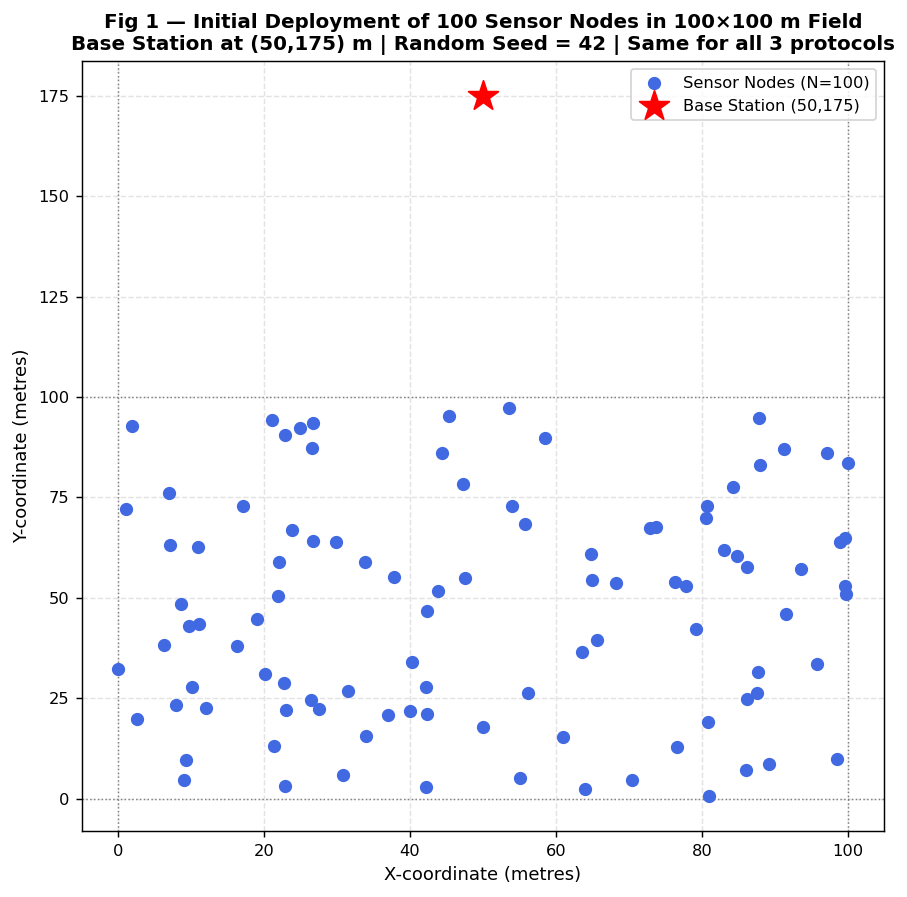

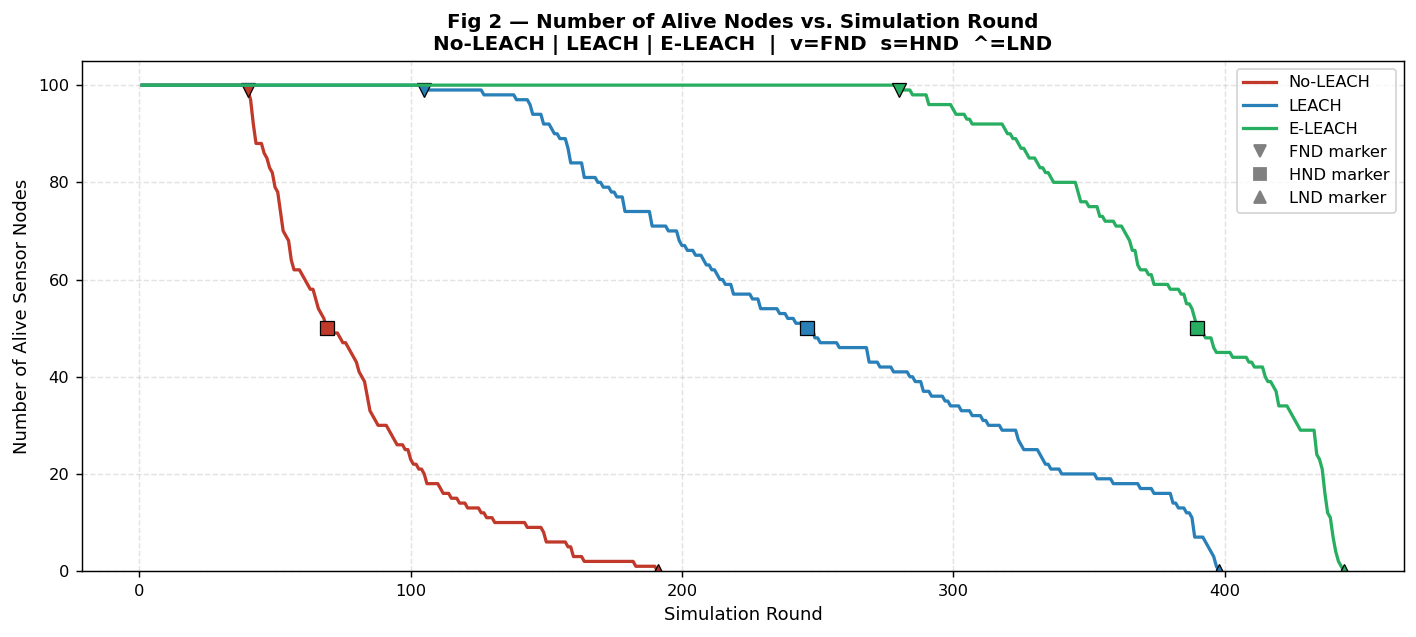

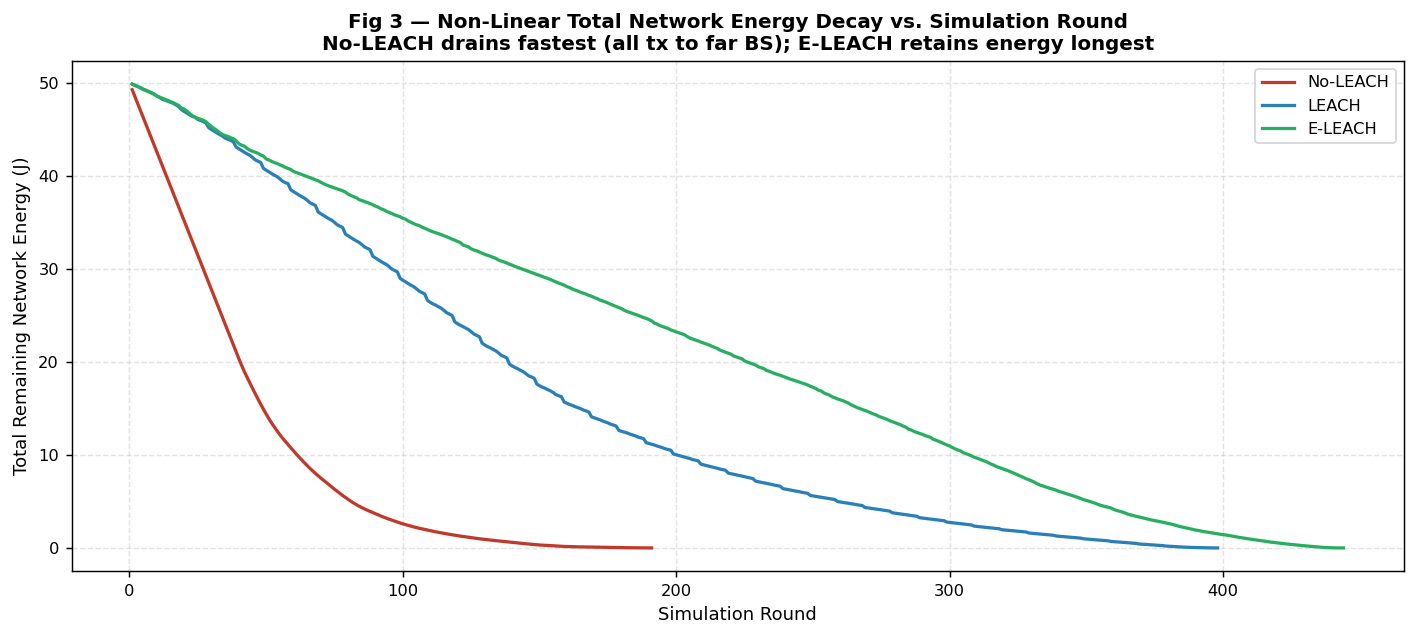

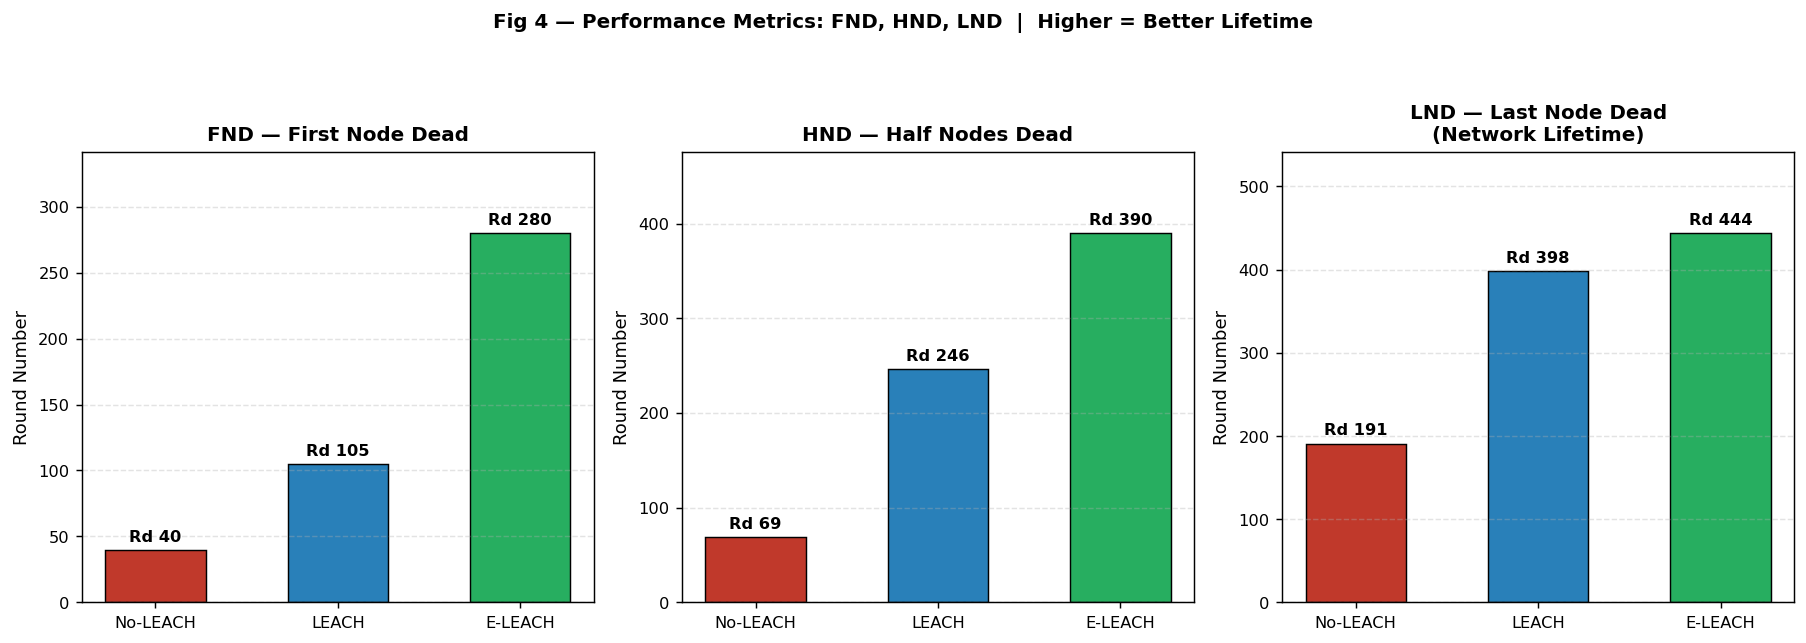

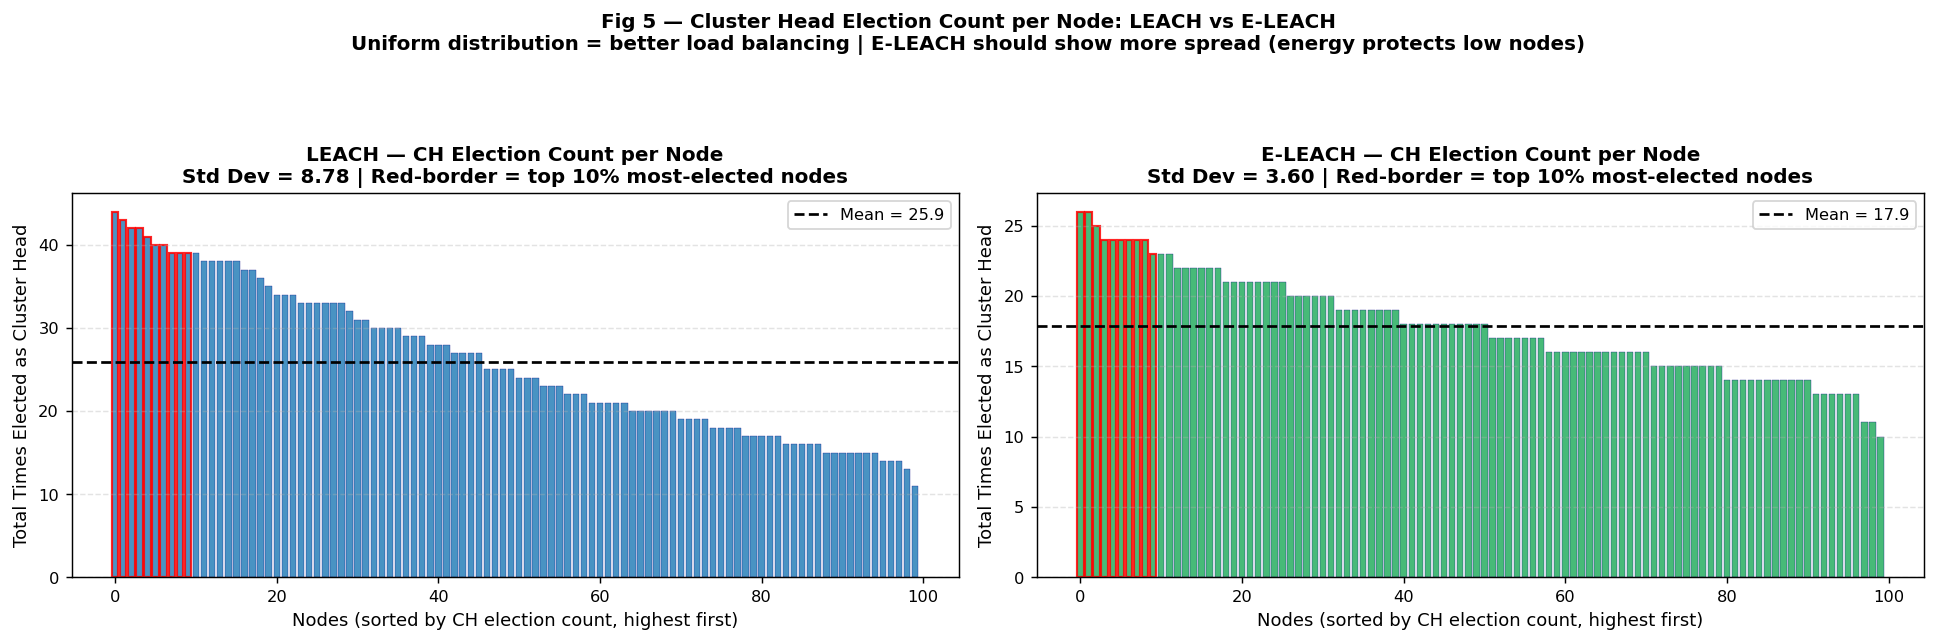

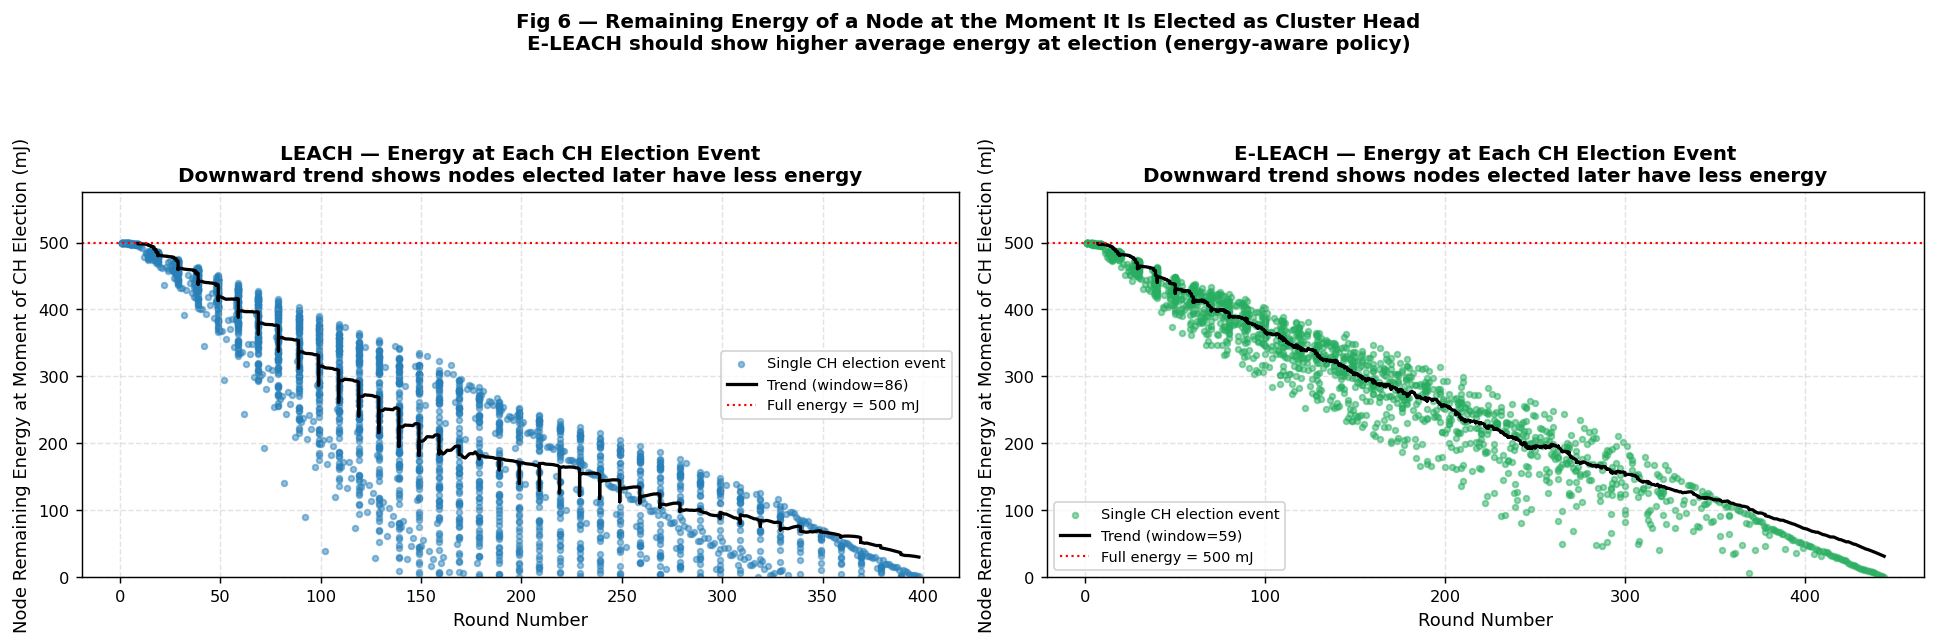

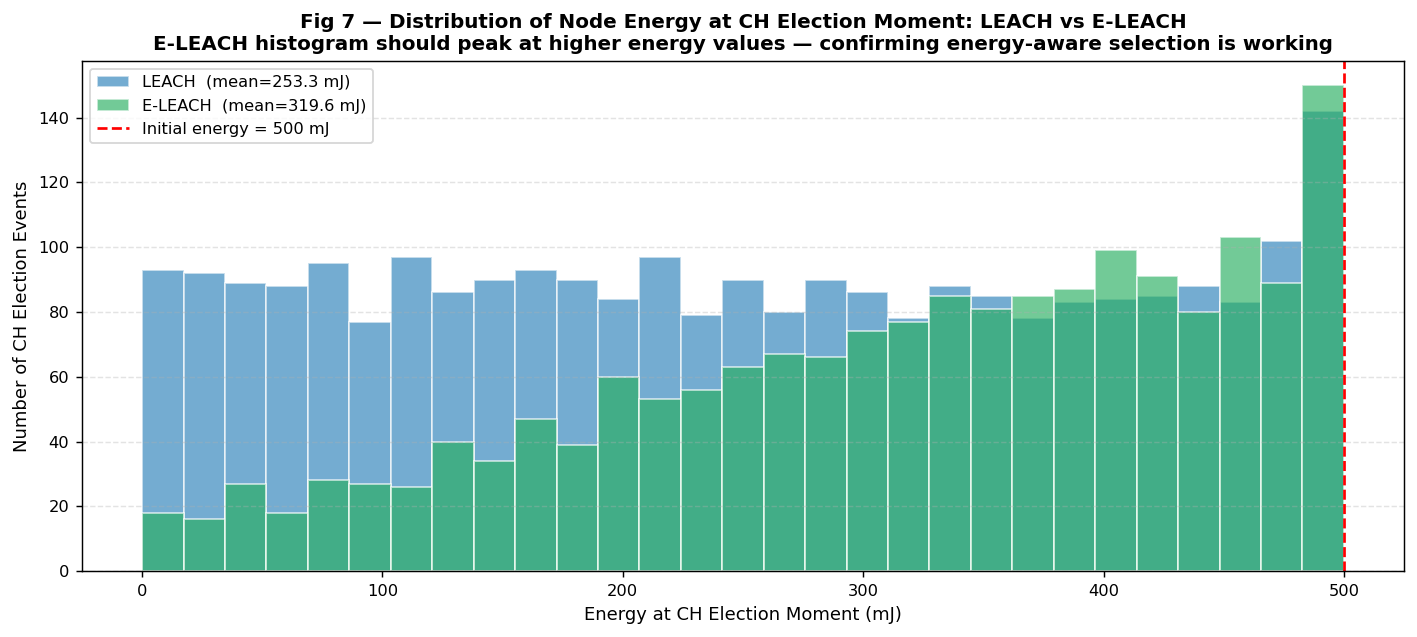

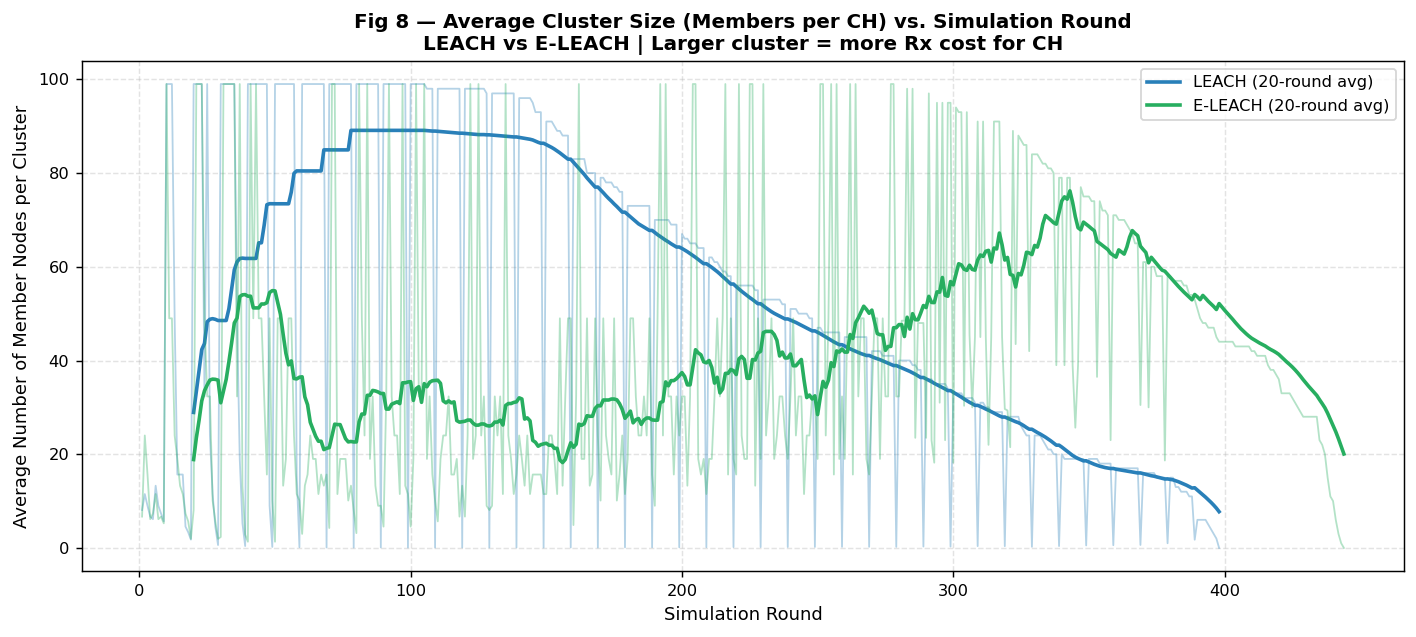

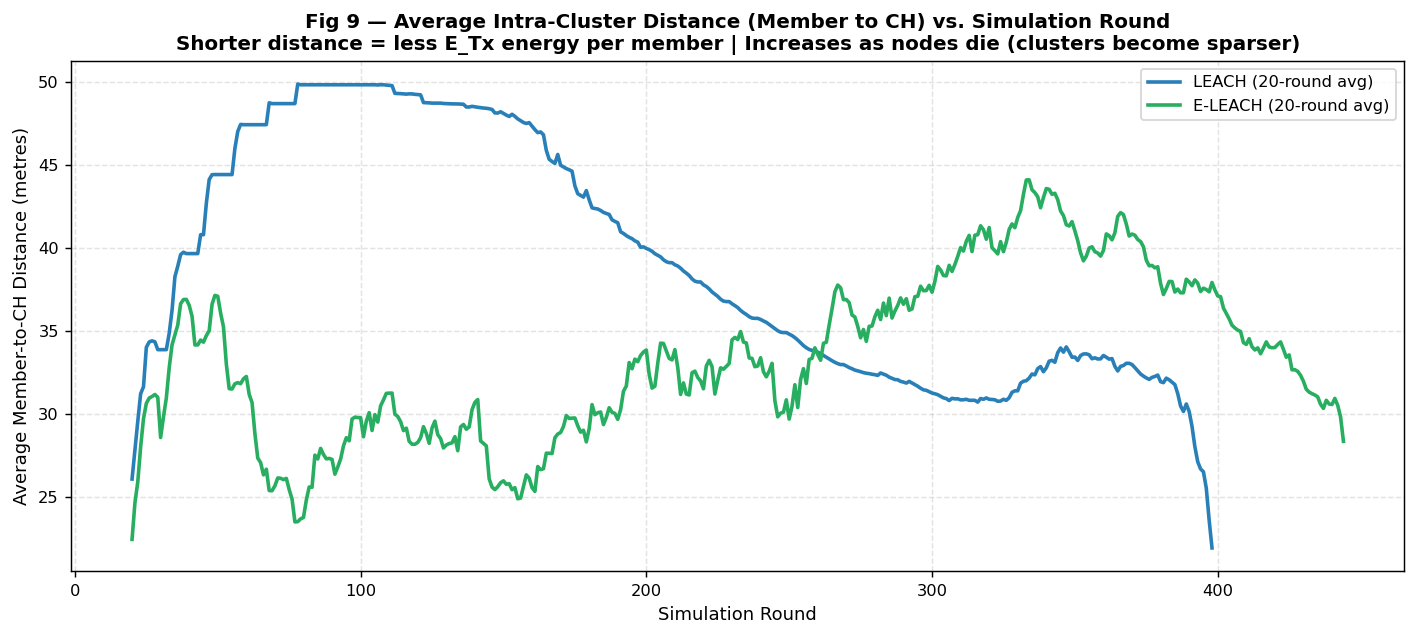

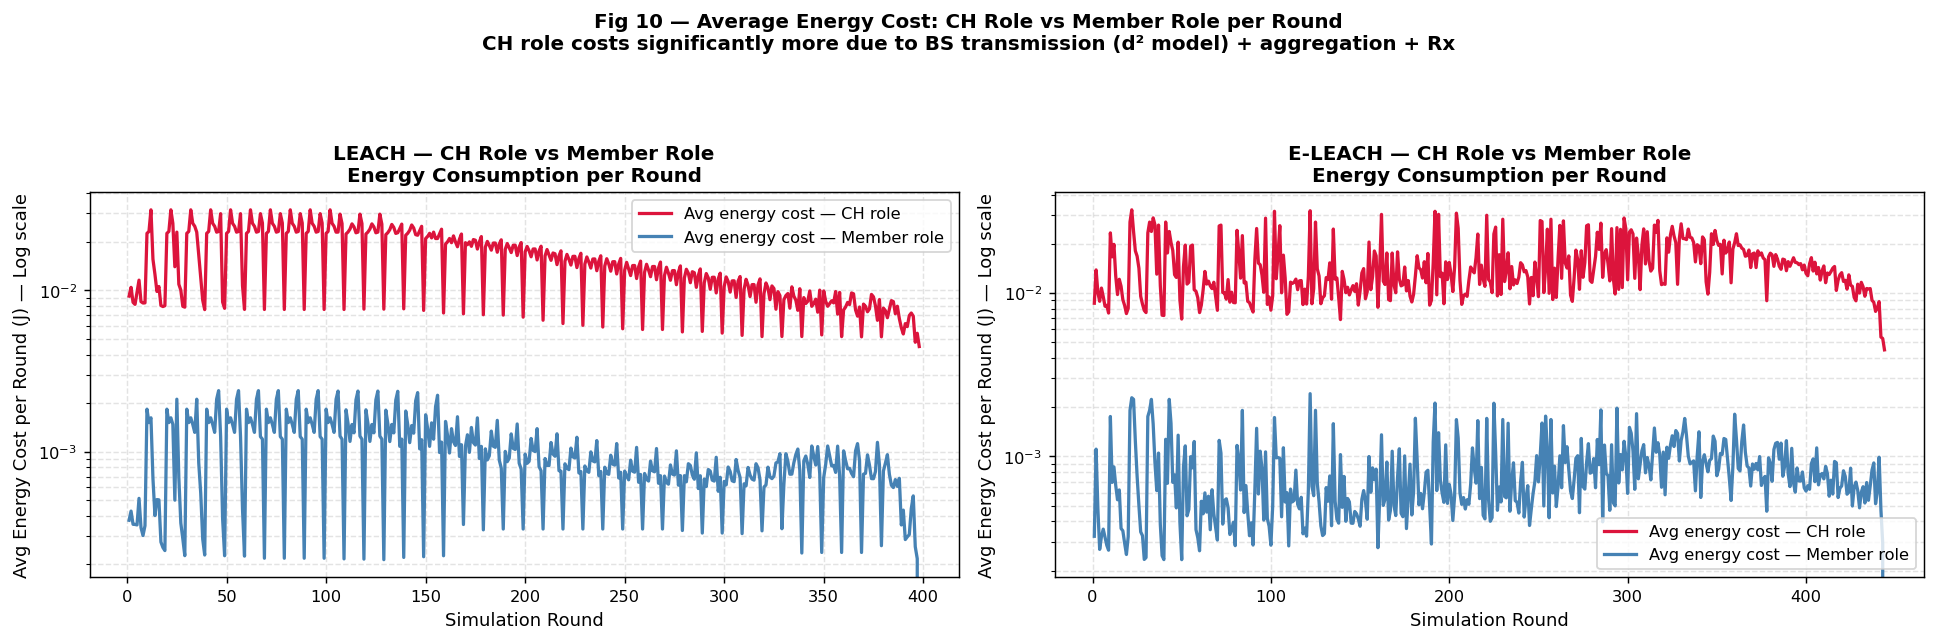

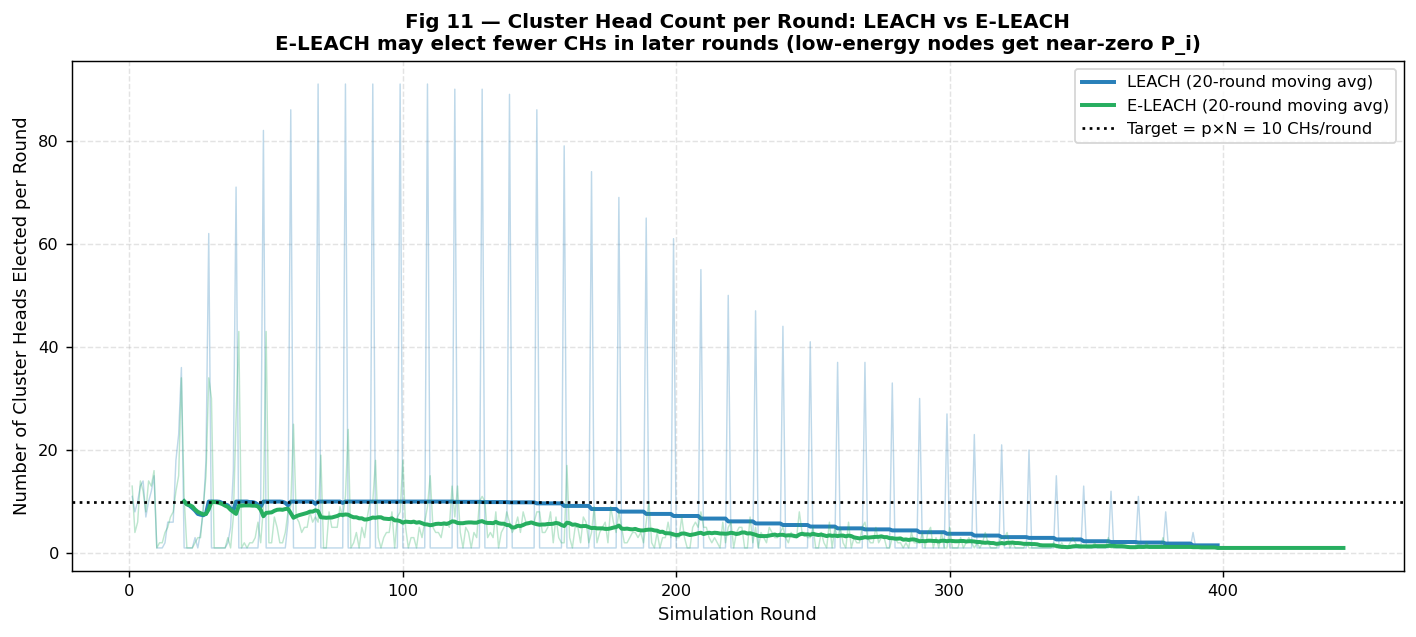

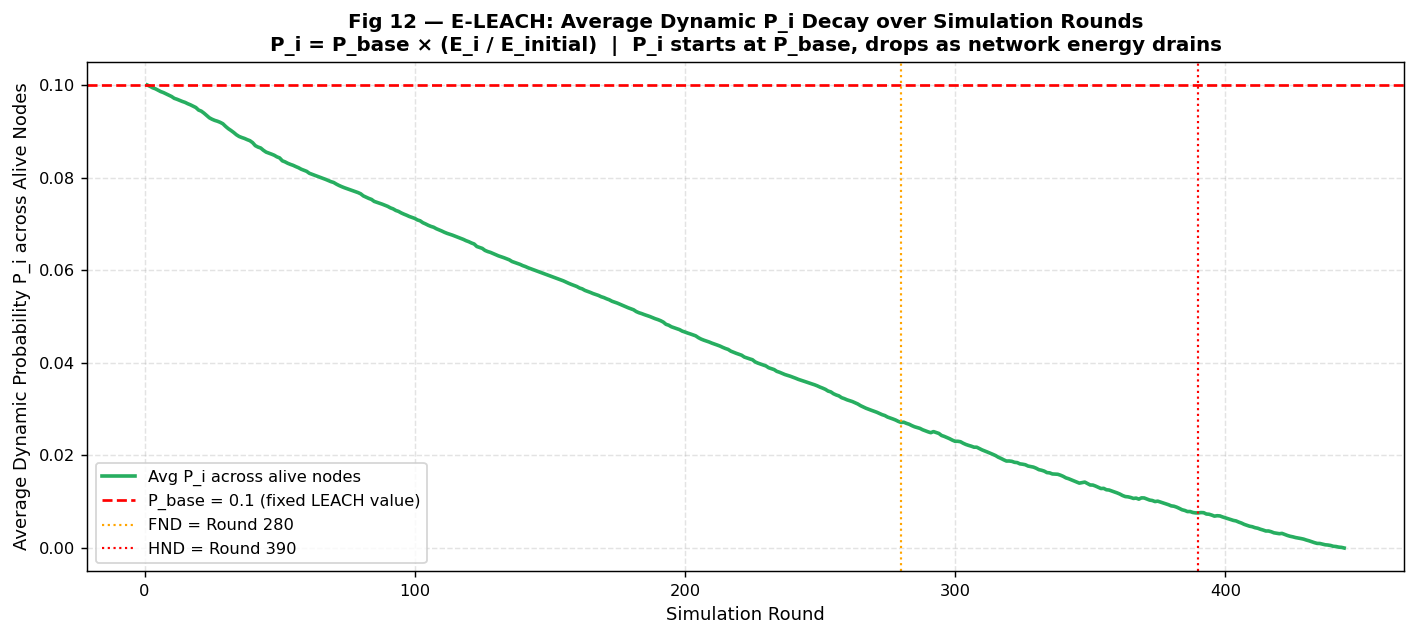

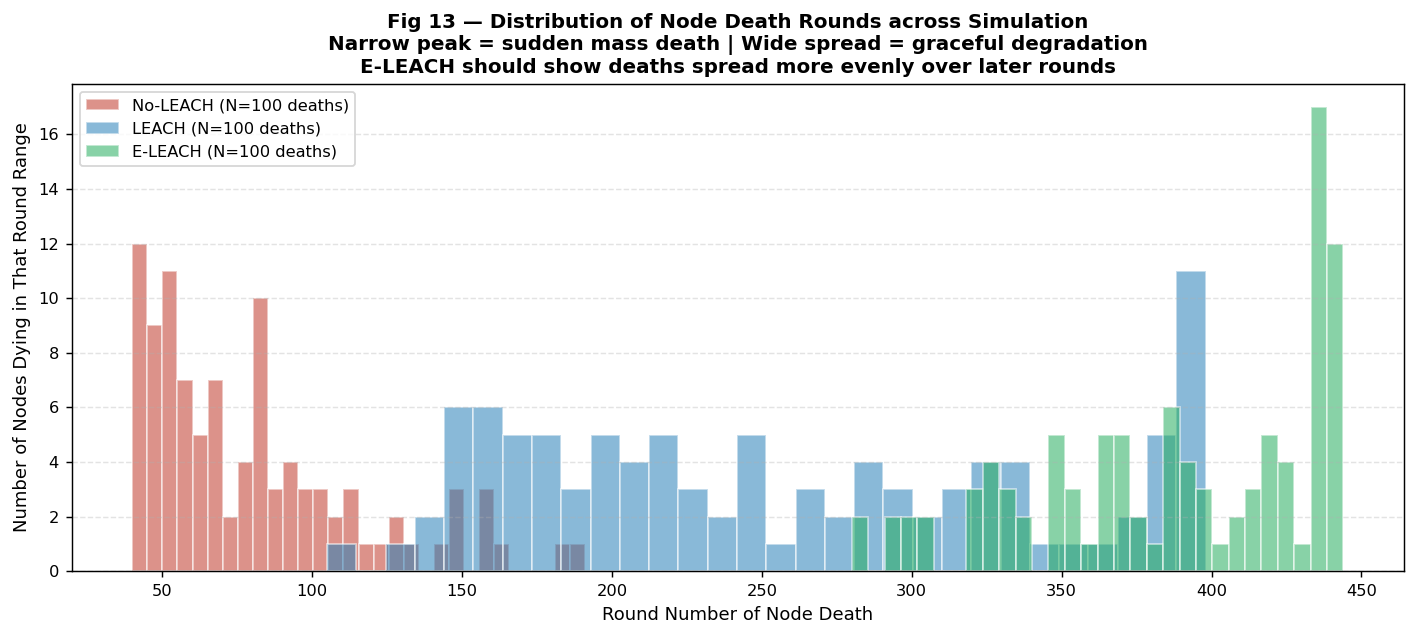

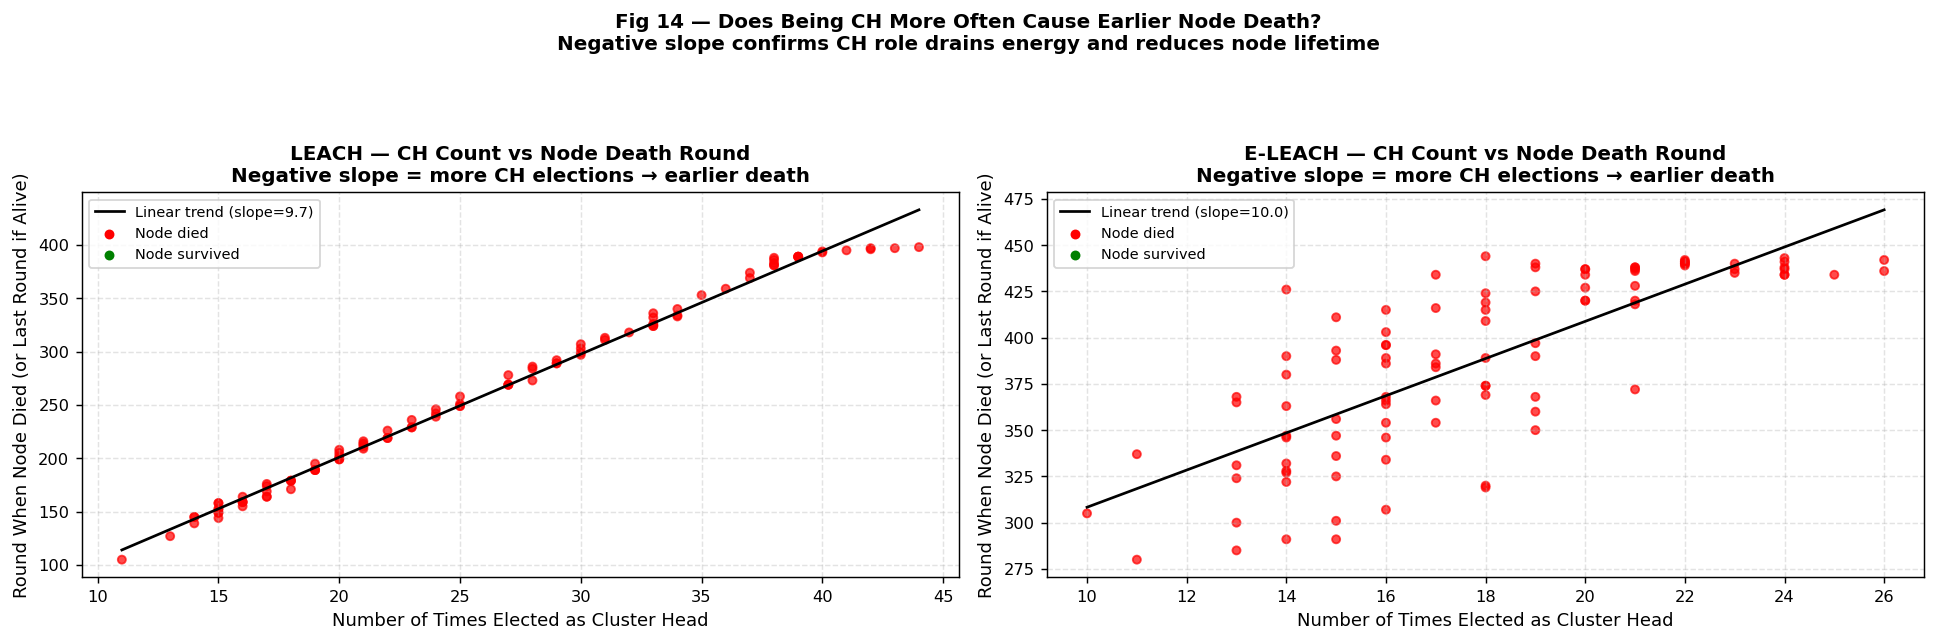

/tmp/ipykernel_36324/3409181427.py:1072: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([leach_sizes, eleach_sizes],


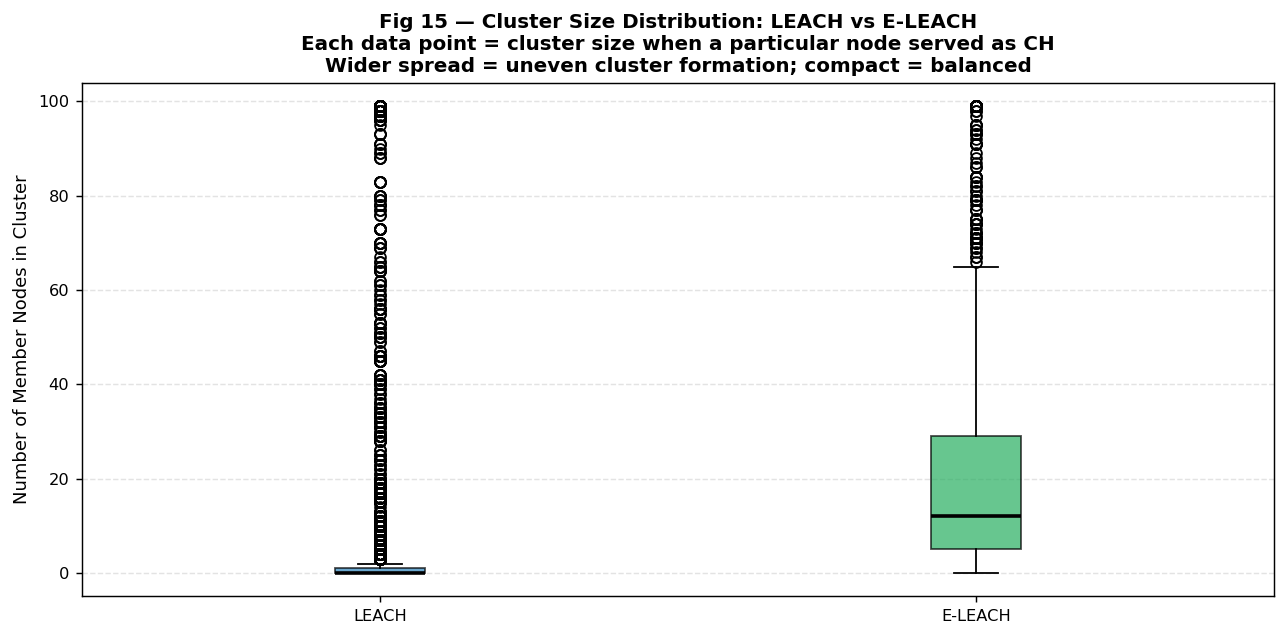

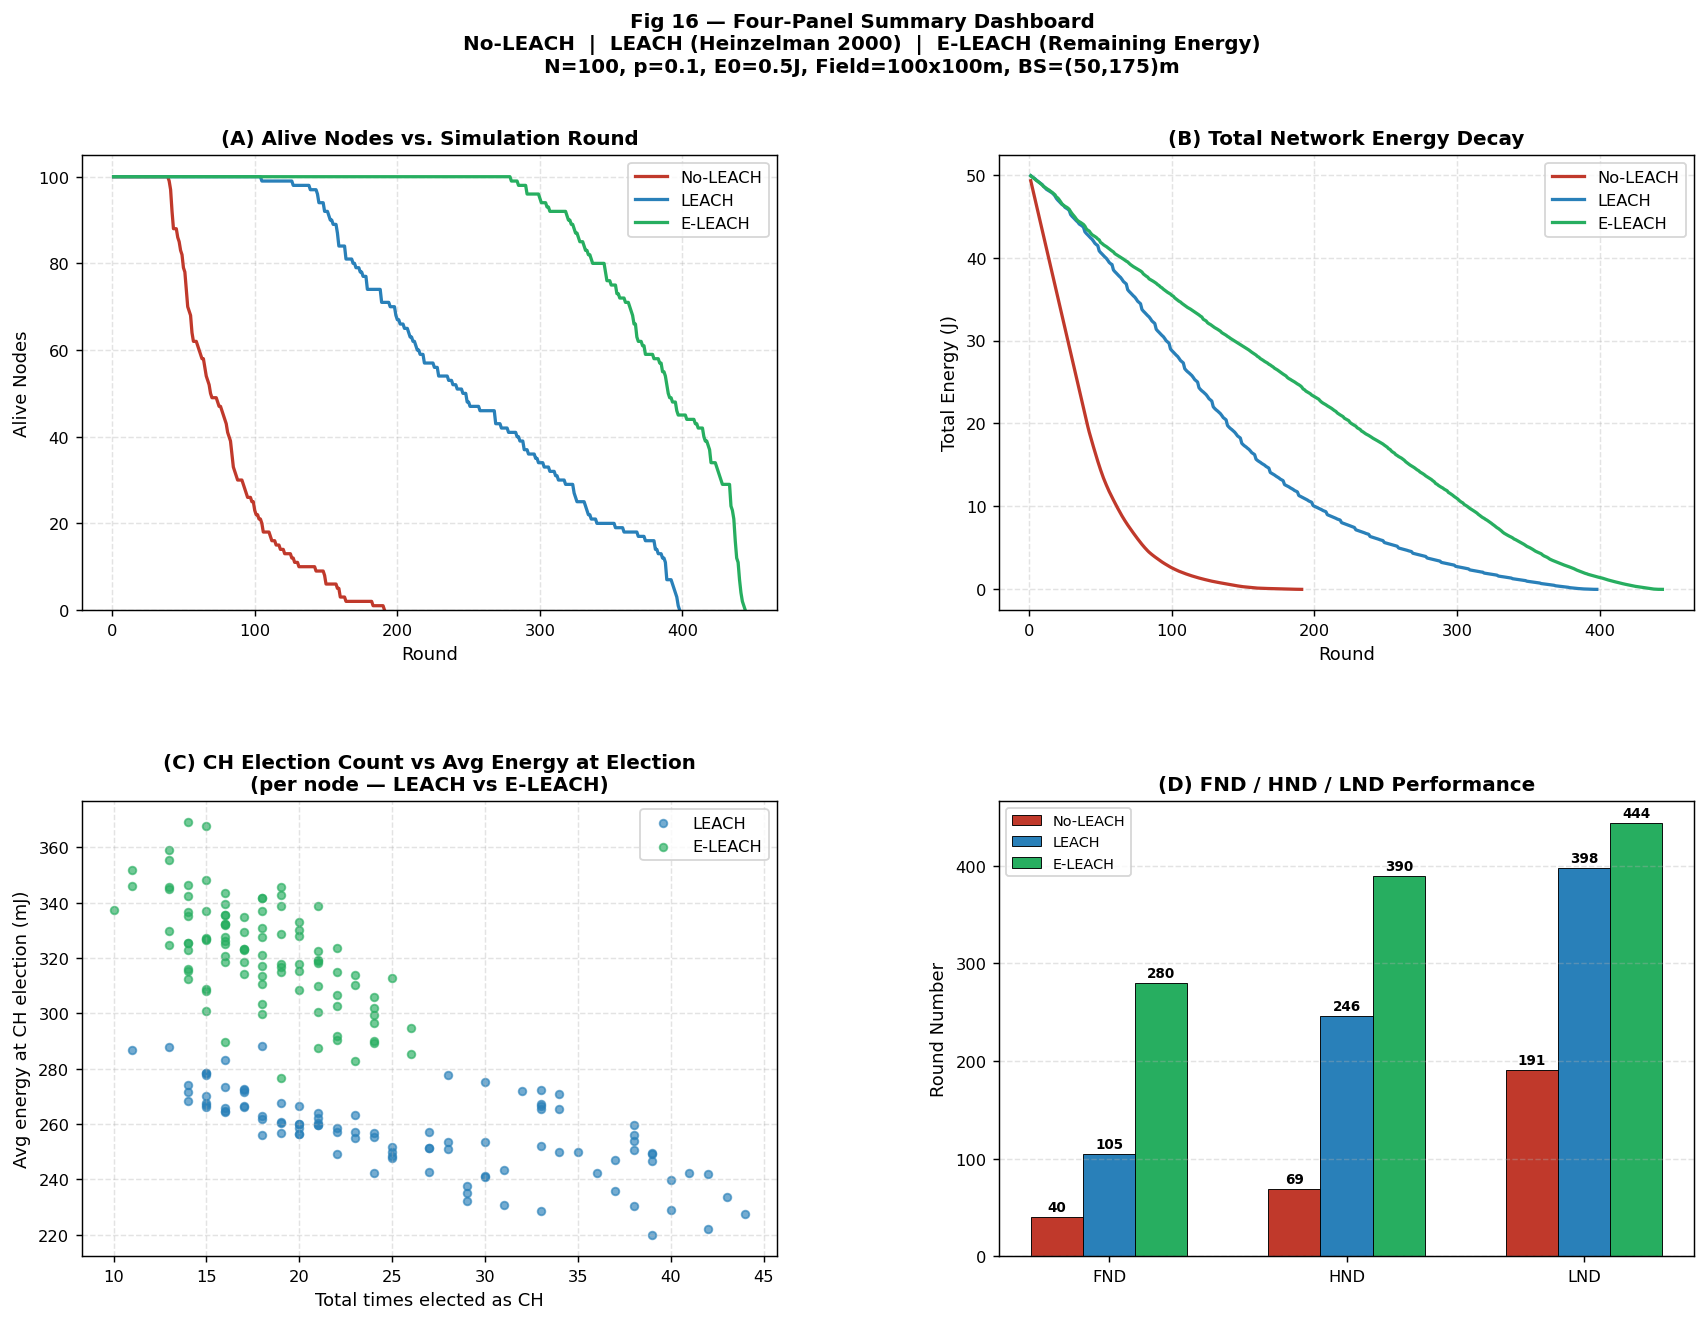


  FINAL SUMMARY — COMPLETE RESULTS

  [LEACH]
  FND / HND / LND              : 105 / 246 / 398
  Total CH elections           : 2592
  Avg CH elections per node    : 25.92
  Std dev CH elections         : 8.78
  Avg energy at CH election    : 253.275 mJ
  Min energy at CH election    : 0.033 mJ
  Avg cluster size (members)   : 9.0
  Nodes that were NEVER CH     : 0
  Top 5 most-elected CH nodes  :
    Node  32: CH  44 times | avg E=227.46mJ | avg cluster=5.2 | died Rd 398
    Node  10: CH  43 times | avg E=233.54mJ | avg cluster=6.5 | died Rd 397
    Node  15: CH  42 times | avg E=241.76mJ | avg cluster=8.0 | died Rd 397
    Node  64: CH  42 times | avg E=221.87mJ | avg cluster=3.3 | died Rd 396
    Node   7: CH  41 times | avg E=242.35mJ | avg cluster=4.4 | died Rd 395

  [E-LEACH]
  FND / HND / LND              : 280 / 390 / 444
  Total CH elections           : 1786
  Avg CH elections per node    : 17.86
  Std dev CH elections         : 3.60
  Avg energy at CH election    : 319.638 

In [4]:
"""
================================================================================
                         M.TECH LAB PROJECT
  EXPERIMENT: Enhanced Comparative Study of Three Routing Protocols
              Protocol 1 : No-LEACH   (Direct Transmission — No Clustering)
              Protocol 2 : LEACH      (Original Heinzelman Algorithm, 2000)
              Protocol 3 : E-LEACH    (LEACH with Remaining-Energy-Based P)

  References:
    [1] Heinzelman et al. (2000). HICSS-33. DOI: 10.1109/HICSS.2000.926982
    [2] Heinzelman et al. (2002). IEEE Trans. Wireless Commun., 1(4), 660-670.
    [3] Smaragdakis et al. (2004). SEP Protocol. SANPA Workshop.
================================================================================
"""

# ==============================================================================
# SECTION 0 — IMPORTS
# ==============================================================================
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 130,
    'lines.linewidth'  : 1.8,
    'grid.alpha'       : 0.35,
    'grid.linestyle'   : '--',
    'legend.fontsize'  : 9,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})


# ==============================================================================
# SECTION 1 — GLOBAL PARAMETERS  (SHARED BY ALL THREE PROTOCOLS)
# ==============================================================================
NUM_NODES      = 100          # Total sensor nodes (N)
FIELD_X        = 100          # Field width  (m)
FIELD_Y        = 100          # Field height (m)
RANDOM_SEED    = 42           # Fixed seed → same positions for all protocols

BS_X           = 50           # Base station X (m) — outside field (Heinzelman 2000)
BS_Y           = 175          # Base station Y (m) — outside field

INIT_ENERGY    = 0.5          # Initial energy per node E_0 = 0.5 J  (Table 1)
E_ELEC         = 50e-9        # Electronics: 50 nJ/bit
EPS_AMP        = 100e-12      # Amplifier:  100 pJ/bit/m^2
E_DA           = 5e-9         # Aggregation:  5 nJ/bit/signal
K_BITS         = 4000         # Packet size: 4000 bits

P_LEACH        = 0.1          # Desired CH fraction = 10%
DEAD_THRESHOLD = 0.0          # Node declared dead when energy <= 0
MAX_ROUNDS     = 5000         # Safety cap

print("=" * 72)
print("  M.TECH ACN LAB — 3-PROTOCOL COMPARISON ")
print("  No-LEACH  |  LEACH (Heinzelman 2000)  |  E-LEACH")
print("=" * 72)
print(f"  Field: {FIELD_X}x{FIELD_Y}m  |  N={NUM_NODES}  |  E0={INIT_ENERGY}J  |"
      f"  p={P_LEACH}  |  BS=({BS_X},{BS_Y})m")


# ==============================================================================
# SECTION 2 — NODE CLASS  (enhanced tracking)
# ==============================================================================

class SensorNode:
    """
    Sensor node with full per-node history tracking.

    New tracked attributes:
      energy_at_ch_election : list of energy values at each CH election moment
                              → shows how healthy/drained the node was when chosen
      ch_election_rounds    : list of round numbers when node was elected CH
                              → lets us see CH rotation pattern over time
      cluster_size_when_ch  : list of cluster sizes when node served as CH
                              → reveals workload per CH election
      death_round           : round number when this node died (or None)
      energy_log            : energy at the end of every round
                              → enables per-node energy trajectory plots
      role_log              : 'CH' or 'M' (member) or 'D' (dead) each round
                              → role history for analysis
    """
    def __init__(self, node_id: int, x: float, y: float):
        self.node_id               = node_id
        self.x                     = x
        self.y                     = y
        self.energy                = INIT_ENERGY
        self.is_alive              = True
        self.is_CH                 = False
        self.my_CH_id              = None
        self.last_CH_round         = -(int(1 / P_LEACH) + 1)

        # ── New tracking fields ───────────────────────────────────────────
        self.ch_count              = 0       # Total CH elections
        self.energy_at_ch_election = []      # Energy at each CH election moment
        self.ch_election_rounds    = []      # Which rounds this node was CH
        self.cluster_size_when_ch  = []      # How many members in cluster each CH turn
        self.death_round           = None    # Round of death (None = survived)
        self.energy_log            = [INIT_ENERGY]  # Energy after each round
        self.role_log              = []      # 'CH', 'M', or 'D' each round

    def record_ch_election(self, round_num: int, cluster_size: int):
        """Call this immediately when node is elected CH this round."""
        self.ch_count             += 1
        self.energy_at_ch_election.append(self.energy)   # Record BEFORE energy drain
        self.ch_election_rounds.append(round_num)
        self.cluster_size_when_ch.append(cluster_size)   # Filled after cluster formation


# ==============================================================================
# SECTION 3 — SHARED HELPERS
# ==============================================================================

def make_nodes() -> list:
    random.seed(RANDOM_SEED)
    return [SensorNode(i,
                       random.uniform(0, FIELD_X),
                       random.uniform(0, FIELD_Y))
            for i in range(NUM_NODES)]


def dist(x1, y1, x2, y2) -> float:
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)


def E_tx(bits, d):
    """E_Tx(k,d) = E_elec*k + eps_amp*k*d^2  (Heinzelman 2000, Eq.1)"""
    return E_ELEC * bits + EPS_AMP * bits * d**2


def E_rx(bits):
    """E_Rx(k) = E_elec*k  (Heinzelman 2000, Eq.2)"""
    return E_ELEC * bits


def E_agg(bits):
    """E_agg(k) = E_DA*k"""
    return E_DA * bits


def check_deaths(nodes, round_num, dead_count, fnd, hnd, lnd):
    """Mark newly dead nodes and update FND/HND/LND milestones."""
    for node in nodes:
        if node.is_alive and node.energy <= DEAD_THRESHOLD:
            node.is_alive    = False
            node.energy      = 0.0
            node.death_round = round_num
            dead_count      += 1
            if fnd is None:
                fnd = round_num
            if dead_count == NUM_NODES // 2 and hnd is None:
                hnd = round_num
            if dead_count == NUM_NODES and lnd is None:
                lnd = round_num
    return dead_count, fnd, hnd, lnd


def smooth(data, w=20):
    """Moving average smoothing — used for noisy per-round curves."""
    if len(data) <= w:
        return data
    return list(np.convolve(data, np.ones(w) / w, mode='valid'))


# ==============================================================================
# SECTION 4 — PROTOCOL 1: NO-LEACH  (Direct Transmission)
# ==============================================================================

def run_no_leach(nodes_in: list) -> dict:
    """
    Every alive node transmits directly to the Base Station every round.
    No clustering, no CH election, no load balancing.
    Energy formula: E_round(n) = E_Tx(k, d(n, BS))
    """
    print("\n" + "-" * 72)
    print("  RUNNING PROTOCOL 1 — No-LEACH (Direct Transmission)")
    print("-" * 72)

    nodes      = copy.deepcopy(nodes_in)
    round_num  = 0
    dead_count = 0
    fnd = hnd = lnd = None

    alive_hist  = []
    energy_hist = []
    dead_hist   = []
    # Per-round avg energy consumed per node (for comparison plot)
    energy_consumed_hist = []

    while dead_count < NUM_NODES and round_num < MAX_ROUNDS:
        round_num += 1
        alive_nodes = [n for n in nodes if n.is_alive]
        if not alive_nodes:
            break

        round_energy_consumed = 0.0
        for node in alive_nodes:
            d_bs  = dist(node.x, node.y, BS_X, BS_Y)
            cost  = E_tx(K_BITS, d_bs)
            node.energy -= cost
            round_energy_consumed += cost
            node.role_log.append('D' if not node.is_alive else 'M')

        dead_count, fnd, hnd, lnd = check_deaths(
            nodes, round_num, dead_count, fnd, hnd, lnd)

        n_alive = sum(1 for n in nodes if n.is_alive)
        alive_hist.append(n_alive)
        dead_hist.append(NUM_NODES - n_alive)
        energy_hist.append(sum(n.energy for n in nodes if n.is_alive))
        energy_consumed_hist.append(
            round_energy_consumed / max(len(alive_nodes), 1))

        for node in nodes:
            node.energy_log.append(node.energy if node.is_alive else 0.0)

    print(f"  FND={fnd}  HND={hnd}  LND={lnd}  Total Rounds={round_num}")
    return {
        'label'                : 'No-LEACH (Direct Tx)',
        'short_label'          : 'No-LEACH',
        'color'                : '#c0392b',
        'marker'               : 's',
        'alive_hist'           : alive_hist,
        'energy_hist'          : energy_hist,
        'dead_hist'            : dead_hist,
        'energy_consumed_hist' : energy_consumed_hist,
        'fnd'  : fnd,  'hnd'  : hnd,  'lnd'  : lnd,
        'rounds': round_num,
        'nodes' : nodes,
    }


# ==============================================================================
# SECTION 5 — PROTOCOL 2: LEACH  (Heinzelman 2000)
# ==============================================================================

def leach_threshold(node, r):
    """
    T(n) = p / (1 - p*(r mod 1/p))   if n in G (not been CH in last 1/p rounds)
         = 0                           otherwise
    Source: Section 3.1, Heinzelman (2000).
    """
    epoch = int(1 / P_LEACH)
    if (r - node.last_CH_round) < epoch:
        return 0.0
    r_mod = r % epoch or epoch
    denom = 1.0 - P_LEACH * r_mod
    return min(P_LEACH / denom, 1.0) if denom > 0 else 1.0


def run_leach(nodes_in: list) -> dict:
    """
    Original LEACH: probabilistic CH election with fixed p=0.1.
    Records full per-node CH history including energy at election and cluster size.
    """
    print("\n" + "-" * 72)
    print("  RUNNING PROTOCOL 2 — Original LEACH (Heinzelman et al., 2000)")
    print("-" * 72)

    nodes      = copy.deepcopy(nodes_in)
    round_num  = 0
    dead_count = 0
    fnd = hnd = lnd = None

    alive_hist           = []
    energy_hist          = []
    dead_hist            = []
    ch_count_hist        = []
    energy_consumed_hist = []

    # Per-round intra-cluster avg distance (member → CH)
    avg_intra_dist_hist  = []
    # Per-round avg cluster size
    avg_cluster_size_hist = []
    # Per-round energy cost: avg for CH role vs avg for member role
    avg_ch_cost_hist     = []
    avg_mem_cost_hist    = []

    while dead_count < NUM_NODES and round_num < MAX_ROUNDS:
        round_num += 1

        for n in nodes:
            n.is_CH    = False
            n.my_CH_id = None

        alive_nodes = [n for n in nodes if n.is_alive]
        if not alive_nodes:
            break

        # ── Setup Phase: CH Election ─────────────────────────────────────
        cluster_heads = []
        for node in alive_nodes:
            if random.uniform(0, 1) < leach_threshold(node, round_num):
                node.is_CH         = True
                node.last_CH_round = round_num
                # Record energy at election moment (BEFORE this round's drain)
                node.energy_at_ch_election.append(node.energy)
                node.ch_election_rounds.append(round_num)
                node.ch_count += 1
                cluster_heads.append(node)

        if not cluster_heads:
            eligible = [n for n in alive_nodes
                        if (round_num - n.last_CH_round) >= int(1/P_LEACH)] or alive_nodes
            best = max(eligible, key=lambda n: n.energy)
            best.is_CH = True
            best.last_CH_round = round_num
            best.energy_at_ch_election.append(best.energy)
            best.ch_election_rounds.append(round_num)
            best.ch_count += 1
            cluster_heads.append(best)

        ch_count_hist.append(len(cluster_heads))

        # ── Setup Phase: Cluster Formation ──────────────────────────────
        cluster_members = defaultdict(list)  # ch_id -> list of member nodes
        intra_dists     = []

        for node in alive_nodes:
            if node.is_CH:
                continue
            best_ch, best_d = None, float('inf')
            for ch in cluster_heads:
                d = dist(node.x, node.y, ch.x, ch.y)
                if d < best_d:
                    best_d, best_ch = d, ch
            if best_ch:
                node.my_CH_id = best_ch.node_id
                cluster_members[best_ch.node_id].append(node)
                intra_dists.append(best_d)

        # Record cluster size for each CH (now that we know membership)
        for ch in cluster_heads:
            ch.cluster_size_when_ch.append(len(cluster_members[ch.node_id]))

        avg_intra_dist_hist.append(
            np.mean(intra_dists) if intra_dists else 0.0)
        avg_cluster_size_hist.append(
            np.mean([len(v) for v in cluster_members.values()]) if cluster_members else 0.0)

        # ── Steady-State: Members → CH ──────────────────────────────────
        ch_costs  = []
        mem_costs = []

        for node in alive_nodes:
            if node.is_CH or node.my_CH_id is None:
                continue
            ch = nodes[node.my_CH_id]
            if not ch.is_alive:
                continue
            d    = dist(node.x, node.y, ch.x, ch.y)
            cost = E_tx(K_BITS, d)
            node.energy -= cost
            ch.energy   -= E_rx(K_BITS)
            mem_costs.append(cost)
            node.role_log.append('M')

        # ── Steady-State: CH → Base Station ─────────────────────────────
        for ch in cluster_heads:
            if not ch.is_alive:
                continue
            d_bs = dist(ch.x, ch.y, BS_X, BS_Y)
            agg_cost = E_agg(K_BITS)
            tx_cost  = E_tx(K_BITS, d_bs)
            ch.energy -= (agg_cost + tx_cost)
            ch_costs.append(agg_cost + tx_cost + E_rx(K_BITS) * len(cluster_members[ch.node_id]))
            ch.role_log.append('CH')

        avg_ch_cost_hist.append(np.mean(ch_costs)   if ch_costs  else 0.0)
        avg_mem_cost_hist.append(np.mean(mem_costs)  if mem_costs else 0.0)

        dead_count, fnd, hnd, lnd = check_deaths(
            nodes, round_num, dead_count, fnd, hnd, lnd)

        n_alive = sum(1 for n in nodes if n.is_alive)
        alive_hist.append(n_alive)
        dead_hist.append(NUM_NODES - n_alive)
        energy_hist.append(sum(n.energy for n in nodes if n.is_alive))
        energy_consumed_hist.append(
            (np.mean(ch_costs) if ch_costs else 0) +
            (np.mean(mem_costs) if mem_costs else 0))

        for node in nodes:
            node.energy_log.append(node.energy if node.is_alive else 0.0)

    print(f"  FND={fnd}  HND={hnd}  LND={lnd}  Total Rounds={round_num}")

    return {
        'label'                 : 'LEACH (Heinzelman 2000)',
        'short_label'           : 'LEACH',
        'color'                 : '#2980b9',
        'marker'                : 'o',
        'alive_hist'            : alive_hist,
        'energy_hist'           : energy_hist,
        'dead_hist'             : dead_hist,
        'ch_count_hist'         : ch_count_hist,
        'energy_consumed_hist'  : energy_consumed_hist,
        'avg_intra_dist_hist'   : avg_intra_dist_hist,
        'avg_cluster_size_hist' : avg_cluster_size_hist,
        'avg_ch_cost_hist'      : avg_ch_cost_hist,
        'avg_mem_cost_hist'     : avg_mem_cost_hist,
        'fnd'   : fnd,  'hnd'  : hnd,  'lnd'  : lnd,
        'rounds': round_num,
        'nodes' : nodes,
    }


# ==============================================================================
# SECTION 6 — PROTOCOL 3: E-LEACH  (Dynamic Energy-Based P)
# ==============================================================================

def e_leach_threshold(node, r):
    """
    Dynamic threshold using energy-weighted probability.
    P_i(r) = P_base * (E_i(r) / E_initial)
    T_i(n) = P_i / (1 - P_i*(r mod 1/P_base))  if eligible
           = 0                                   otherwise
    """
    epoch = int(1 / P_LEACH)
    if (r - node.last_CH_round) < epoch:
        return 0.0
    P_i   = P_LEACH * max(0.0, node.energy / INIT_ENERGY)
    if P_i <= 0:
        return 0.0
    r_mod = r % epoch or epoch
    denom = 1.0 - P_i * r_mod
    return min(P_i / denom, 1.0) if denom > 0 else 1.0


def run_e_leach(nodes_in: list) -> dict:
    """
    E-LEACH: same structure as LEACH but P_i is dynamic per node per round.
    High-energy nodes get higher P_i → more likely to be elected CH.
    Low-energy nodes get lower P_i  → protected from expensive CH role.
    """
    print("\n" + "-" * 72)
    print("  RUNNING PROTOCOL 3 — E-LEACH (Energy-Based Dynamic P)")
    print("-" * 72)

    nodes      = copy.deepcopy(nodes_in)
    round_num  = 0
    dead_count = 0
    fnd = hnd = lnd = None

    alive_hist            = []
    energy_hist           = []
    dead_hist             = []
    ch_count_hist         = []
    energy_consumed_hist  = []
    avg_intra_dist_hist   = []
    avg_cluster_size_hist = []
    avg_ch_cost_hist      = []
    avg_mem_cost_hist     = []
    avg_pi_hist           = []  # E-LEACH only: average P_i per round

    while dead_count < NUM_NODES and round_num < MAX_ROUNDS:
        round_num += 1

        for n in nodes:
            n.is_CH    = False
            n.my_CH_id = None

        alive_nodes = [n for n in nodes if n.is_alive]
        if not alive_nodes:
            break

        # Track average P_i across alive nodes (unique E-LEACH metric)
        avg_pi = np.mean([P_LEACH * (n.energy / INIT_ENERGY) for n in alive_nodes])
        avg_pi_hist.append(avg_pi)

        # ── CH Election ───────────────────────────────────────────────────
        cluster_heads = []
        for node in alive_nodes:
            if random.uniform(0, 1) < e_leach_threshold(node, round_num):
                node.is_CH         = True
                node.last_CH_round = round_num
                node.energy_at_ch_election.append(node.energy)
                node.ch_election_rounds.append(round_num)
                node.ch_count += 1
                cluster_heads.append(node)

        if not cluster_heads:
            eligible = [n for n in alive_nodes
                        if (round_num - n.last_CH_round) >= int(1/P_LEACH)] or alive_nodes
            best = max(eligible, key=lambda n: n.energy)
            best.is_CH = True
            best.last_CH_round = round_num
            best.energy_at_ch_election.append(best.energy)
            best.ch_election_rounds.append(round_num)
            best.ch_count += 1
            cluster_heads.append(best)

        ch_count_hist.append(len(cluster_heads))

        # ── Cluster Formation ─────────────────────────────────────────────
        cluster_members = defaultdict(list)
        intra_dists     = []

        for node in alive_nodes:
            if node.is_CH:
                continue
            best_ch, best_d = None, float('inf')
            for ch in cluster_heads:
                d = dist(node.x, node.y, ch.x, ch.y)
                if d < best_d:
                    best_d, best_ch = d, ch
            if best_ch:
                node.my_CH_id = best_ch.node_id
                cluster_members[best_ch.node_id].append(node)
                intra_dists.append(best_d)

        for ch in cluster_heads:
            ch.cluster_size_when_ch.append(len(cluster_members[ch.node_id]))

        avg_intra_dist_hist.append(
            np.mean(intra_dists) if intra_dists else 0.0)
        avg_cluster_size_hist.append(
            np.mean([len(v) for v in cluster_members.values()]) if cluster_members else 0.0)

        # ── Data Transmission ─────────────────────────────────────────────
        ch_costs  = []
        mem_costs = []

        for node in alive_nodes:
            if node.is_CH or node.my_CH_id is None:
                continue
            ch = nodes[node.my_CH_id]
            if not ch.is_alive:
                continue
            d    = dist(node.x, node.y, ch.x, ch.y)
            cost = E_tx(K_BITS, d)
            node.energy -= cost
            ch.energy   -= E_rx(K_BITS)
            mem_costs.append(cost)
            node.role_log.append('M')

        for ch in cluster_heads:
            if not ch.is_alive:
                continue
            d_bs     = dist(ch.x, ch.y, BS_X, BS_Y)
            agg_cost = E_agg(K_BITS)
            tx_cost  = E_tx(K_BITS, d_bs)
            ch.energy -= (agg_cost + tx_cost)
            ch_costs.append(agg_cost + tx_cost + E_rx(K_BITS) * len(cluster_members[ch.node_id]))
            ch.role_log.append('CH')

        avg_ch_cost_hist.append(np.mean(ch_costs)  if ch_costs  else 0.0)
        avg_mem_cost_hist.append(np.mean(mem_costs) if mem_costs else 0.0)

        dead_count, fnd, hnd, lnd = check_deaths(
            nodes, round_num, dead_count, fnd, hnd, lnd)

        n_alive = sum(1 for n in nodes if n.is_alive)
        alive_hist.append(n_alive)
        dead_hist.append(NUM_NODES - n_alive)
        energy_hist.append(sum(n.energy for n in nodes if n.is_alive))
        energy_consumed_hist.append(
            (np.mean(ch_costs) if ch_costs else 0) +
            (np.mean(mem_costs) if mem_costs else 0))

        for node in nodes:
            node.energy_log.append(node.energy if node.is_alive else 0.0)

    print(f"  FND={fnd}  HND={hnd}  LND={lnd}  Total Rounds={round_num}")

    return {
        'label'                 : 'E-LEACH (Remaining Energy)',
        'short_label'           : 'E-LEACH',
        'color'                 : '#27ae60',
        'marker'                : '^',
        'alive_hist'            : alive_hist,
        'energy_hist'           : energy_hist,
        'dead_hist'             : dead_hist,
        'ch_count_hist'         : ch_count_hist,
        'energy_consumed_hist'  : energy_consumed_hist,
        'avg_intra_dist_hist'   : avg_intra_dist_hist,
        'avg_cluster_size_hist' : avg_cluster_size_hist,
        'avg_ch_cost_hist'      : avg_ch_cost_hist,
        'avg_mem_cost_hist'     : avg_mem_cost_hist,
        'avg_pi_hist'           : avg_pi_hist,
        'fnd'   : fnd,  'hnd'  : hnd,  'lnd'  : lnd,
        'rounds': round_num,
        'nodes' : nodes,
    }


# ==============================================================================
# SECTION 7 — RUN ALL THREE PROTOCOLS
# ==============================================================================
initial_nodes = make_nodes()

print("\n" + "=" * 72)
print("  STARTING SIMULATIONS")
print("=" * 72)

r1 = run_no_leach(initial_nodes)
r2 = run_leach(initial_nodes)
r3 = run_e_leach(initial_nodes)
results    = [r1, r2, r3]
max_rounds = max(r['rounds'] for r in results)


# ==============================================================================
# SECTION 8 — RESULTS TABLES
# ==============================================================================

print("\n" + "=" * 72)
print("  TABLE 1 — NETWORK LIFETIME METRICS")
print("=" * 72)
print(f"  {'Protocol':<28} {'FND':>7} {'HND':>7} {'LND':>7}  {'FND Gain':>10}")
print("  " + "-" * 60)
base_fnd = r1['fnd'] or 1
for r in results:
    gain = f"{(r['fnd'] or 0) / base_fnd:.2f}x" if r['fnd'] else 'N/A'
    print(f"  {r['short_label']:<28} {str(r['fnd']):>7} {str(r['hnd']):>7} "
          f"{str(r['lnd']):>7}  {gain:>10}")

print(f"\n  Improvement LEACH over No-LEACH  : "
      f"FND {r2['fnd']/r1['fnd']:.2f}x  |  LND {r2['lnd']/r1['lnd']:.2f}x")
print(f"  Improvement E-LEACH over LEACH   : "
      f"FND {r3['fnd']/r2['fnd']:.2f}x  |  LND {r3['lnd']/r2['lnd']:.2f}x")
print(f"  Improvement E-LEACH over No-LEACH: "
      f"FND {r3['fnd']/r1['fnd']:.2f}x  |  LND {r3['lnd']/r1['lnd']:.2f}x")

# CH election summary
print("\n" + "=" * 72)
print("  TABLE 2 — CLUSTER HEAD ELECTION ANALYSIS (LEACH vs E-LEACH)")
print("=" * 72)
for r in [r2, r3]:
    nodes_r = r['nodes']
    counts  = [n.ch_count for n in nodes_r]
    print(f"\n  [{r['short_label']}]")
    print(f"  Total CH elections     : {sum(counts)}")
    print(f"  Average per node       : {np.mean(counts):.2f}")
    print(f"  Std deviation          : {np.std(counts):.2f}  "
          f"(lower = more uniform load balancing)")
    print(f"  Max elections (node)   : {max(counts)} "
          f"(Node {counts.index(max(counts))})")
    print(f"  Min elections (node)   : {min(counts)} "
          f"(Node {counts.index(min(counts))})")
    print(f"  Nodes never elected    : {sum(1 for c in counts if c == 0)}")

    # Energy at CH election statistics
    all_energies = []
    for n in nodes_r:
        all_energies.extend(n.energy_at_ch_election)
    if all_energies:
        print(f"  Avg energy at election : {np.mean(all_energies)*1000:.3f} mJ")
        print(f"  Min energy at election : {min(all_energies)*1000:.3f} mJ  "
              f"← node was almost dead when chosen!")
        print(f"  Max energy at election : {max(all_energies)*1000:.3f} mJ")


# ==============================================================================
# SECTION 9 — ALL PLOTS
# ==============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1: Node Deployment Map
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter([n.x for n in initial_nodes],
           [n.y for n in initial_nodes],
           c='royalblue', s=40, zorder=3, label=f'Sensor Nodes (N={NUM_NODES})')
ax.scatter(BS_X, BS_Y, c='red', s=300, marker='*', zorder=5,
           label=f'Base Station ({BS_X},{BS_Y})')
for v in [0, FIELD_X]:
    ax.axvline(v, color='gray', lw=0.8, ls=':')
for h in [0, FIELD_Y]:
    ax.axhline(h, color='gray', lw=0.8, ls=':')
ax.set_xlabel("X-coordinate (metres)")
ax.set_ylabel("Y-coordinate (metres)")
ax.set_title(f"Fig 1 — Initial Deployment of {NUM_NODES} Sensor Nodes in {FIELD_X}×{FIELD_Y} m Field\n"
             f"Base Station at ({BS_X},{BS_Y}) m | Random Seed = {RANDOM_SEED} | "
             "Same for all 3 protocols")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig01_Node_Deployment.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2: Alive Nodes vs Rounds — all 3
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for r in results:
    ax.plot(range(1, r['rounds']+1), r['alive_hist'],
            color=r['color'], label=r['short_label'])
    for key, sym in [('fnd','v'), ('hnd','s'), ('lnd','^')]:
        rnd = r[key]
        if rnd and rnd <= len(r['alive_hist']):
            ax.plot(rnd, r['alive_hist'][rnd-1], sym,
                    color=r['color'], ms=8,
                    mec='black', mew=0.7)
ax.plot([], [], 'v', c='gray', ms=7, label='FND marker')
ax.plot([], [], 's', c='gray', ms=7, label='HND marker')
ax.plot([], [], '^', c='gray', ms=7, label='LND marker')
ax.set_xlabel("Simulation Round")
ax.set_ylabel("Number of Alive Sensor Nodes")
ax.set_title("Fig 2 — Number of Alive Nodes vs. Simulation Round\n"
             "No-LEACH | LEACH | E-LEACH  |  v=FND  s=HND  ^=LND")
ax.set_ylim(0, NUM_NODES+5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig02_Alive_Nodes_Comparison.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3: Total Network Energy Decay — Non-Linear — all 3
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for r in results:
    ax.plot(range(1, r['rounds']+1), r['energy_hist'],
            color=r['color'], label=r['short_label'])
ax.set_xlabel("Simulation Round")
ax.set_ylabel("Total Remaining Network Energy (J)")
ax.set_title("Fig 3 — Non-Linear Total Network Energy Decay vs. Simulation Round\n"
             "No-LEACH drains fastest (all tx to far BS); "
             "E-LEACH retains energy longest")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig03_Energy_Decay_Comparison.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4: FND / HND / LND Bar Chart (grouped)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, key, title in zip(axes,
                           ['fnd', 'hnd', 'lnd'],
                           ['FND — First Node Dead',
                            'HND — Half Nodes Dead',
                            'LND — Last Node Dead\n(Network Lifetime)']):
    vals   = [r[key] or 0 for r in results]
    labels = [r['short_label'] for r in results]
    colors = [r['color'] for r in results]
    bars   = ax.bar(labels, vals, color=colors, edgecolor='black', lw=0.8, width=0.55)
    for bar, v in zip(bars, vals):
        if v:
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + max(vals)*0.015,
                    f'Rd {v}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')
    ax.set_ylabel("Round Number")
    ax.set_title(title)
    ax.set_ylim(0, max(v for v in vals if v) * 1.22)
    ax.grid(True, axis='y')
fig.suptitle("Fig 4 — Performance Metrics: FND, HND, LND  |  Higher = Better Lifetime",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Fig04_FND_HND_LND_Bar.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 5: CH Election Count per Node — LEACH
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, r in zip(axes, [r2, r3]):
    counts = [n.ch_count for n in r['nodes']]
    ids    = list(range(NUM_NODES))
    sorted_pairs = sorted(zip(counts, ids), reverse=True)
    sc, si = zip(*sorted_pairs)

    bars = ax.bar(range(NUM_NODES), sc,
                  color=r['color'], edgecolor='navy', lw=0.2, alpha=0.85)
    avg = np.mean(sc)
    ax.axhline(avg, color='black', ls='--', lw=1.5,
               label=f'Mean = {avg:.1f}')

    # Shade top 10% nodes
    top10 = int(NUM_NODES * 0.1)
    for i in range(top10):
        bars[i].set_edgecolor('red')
        bars[i].set_linewidth(1.2)

    ax.set_xlabel("Nodes (sorted by CH election count, highest first)")
    ax.set_ylabel("Total Times Elected as Cluster Head")
    ax.set_title(f"{r['short_label']} — CH Election Count per Node\n"
                 f"Std Dev = {np.std(sc):.2f} | "
                 f"Red-border = top 10% most-elected nodes")
    ax.legend()
    ax.grid(True, axis='y')

fig.suptitle("Fig 5 — Cluster Head Election Count per Node: LEACH vs E-LEACH\n"
             "Uniform distribution = better load balancing | "
             "E-LEACH should show more spread (energy protects low nodes)",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig05_CH_Count_per_Node.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 6: Remaining Energy at CH Election — LEACH vs E-LEACH
# KEY PLOT: shows E-LEACH avoids electing low-energy nodes as CH
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, r in zip(axes, [r2, r3]):
    nodes_r = r['nodes']

    # Scatter: for each node, plot (CH election round, energy at that moment)
    all_rounds   = []
    all_energies = []
    for n in nodes_r:
        for rnd, eng in zip(n.ch_election_rounds, n.energy_at_ch_election):
            all_rounds.append(rnd)
            all_energies.append(eng * 1000)   # Convert to mJ

    sc = ax.scatter(all_rounds, all_energies,
                    color=r['color'], s=10, alpha=0.5,
                    label='Single CH election event')
    # Trend line (moving average)
    if len(all_rounds) > 30:
        sorted_pairs = sorted(zip(all_rounds, all_energies))
        sr, se = zip(*sorted_pairs)
        w = max(5, len(sr)//30)
        se_sm = smooth(list(se), w)
        ax.plot(list(sr)[w-1:], se_sm, color='black', lw=1.8,
                label=f'Trend (window={w})')

    ax.axhline(INIT_ENERGY * 1000, color='red', ls=':', lw=1.2,
               label=f'Full energy = {INIT_ENERGY*1000:.0f} mJ')

    ax.set_xlabel("Round Number")
    ax.set_ylabel("Node Remaining Energy at Moment of CH Election (mJ)")
    ax.set_title(f"{r['short_label']} — Energy at Each CH Election Event\n"
                 "Downward trend shows nodes elected later have less energy")
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0, INIT_ENERGY * 1000 * 1.15)

fig.suptitle("Fig 6 — Remaining Energy of a Node at the Moment It Is Elected as Cluster Head\n"
             "E-LEACH should show higher average energy at election (energy-aware policy)",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig06_Energy_at_CH_Election.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 7: Energy at CH Election — Distribution Histogram
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, INIT_ENERGY * 1000, 30)
for r in [r2, r3]:
    all_e = []
    for n in r['nodes']:
        all_e.extend([e * 1000 for e in n.energy_at_ch_election])
    ax.hist(all_e, bins=bins, alpha=0.65,
            color=r['color'], edgecolor='white', lw=0.5,
            label=f"{r['short_label']}  (mean={np.mean(all_e):.1f} mJ)")

ax.axvline(INIT_ENERGY * 1000, color='red', ls='--', lw=1.5,
           label=f'Initial energy = {INIT_ENERGY*1000:.0f} mJ')
ax.set_xlabel("Energy at CH Election Moment (mJ)")
ax.set_ylabel("Number of CH Election Events")
ax.set_title("Fig 7 — Distribution of Node Energy at CH Election Moment: LEACH vs E-LEACH\n"
             "E-LEACH histogram should peak at higher energy values — "
             "confirming energy-aware selection is working")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig("Fig07_Energy_at_Election_Histogram.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 8: Average Cluster Size per Round — LEACH vs E-LEACH
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for r in [r2, r3]:
    cs = r.get('avg_cluster_size_hist', [])
    if not cs:
        continue
    ax.plot(range(1, len(cs)+1), cs,
            color=r['color'], alpha=0.35, lw=1.0)
    sm = smooth(cs, 20)
    ax.plot(range(20, len(cs)+1), sm,
            color=r['color'], lw=2.0,
            label=f"{r['short_label']} (20-round avg)")

ax.set_xlabel("Simulation Round")
ax.set_ylabel("Average Number of Member Nodes per Cluster")
ax.set_title("Fig 8 — Average Cluster Size (Members per CH) vs. Simulation Round\n"
             "LEACH vs E-LEACH | Larger cluster = more Rx cost for CH")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig08_Avg_Cluster_Size.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 9: Avg Intra-Cluster Distance (Member→CH) vs Round
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for r in [r2, r3]:
    dd = r.get('avg_intra_dist_hist', [])
    if not dd:
        continue
    sm = smooth(dd, 20)
    ax.plot(range(20, len(dd)+1), sm,
            color=r['color'], lw=2.0,
            label=f"{r['short_label']} (20-round avg)")

ax.set_xlabel("Simulation Round")
ax.set_ylabel("Average Member-to-CH Distance (metres)")
ax.set_title("Fig 9 — Average Intra-Cluster Distance (Member to CH) vs. Simulation Round\n"
             "Shorter distance = less E_Tx energy per member | "
             "Increases as nodes die (clusters become sparser)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig09_Avg_Intra_Cluster_Distance.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 10: CH Cost vs Member Cost per Round  (LEACH and E-LEACH side by side)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, r in zip(axes, [r2, r3]):
    ch_c  = r.get('avg_ch_cost_hist',  [])
    mem_c = r.get('avg_mem_cost_hist', [])
    if not ch_c or not mem_c:
        continue
    rng = range(1, len(ch_c)+1)
    ax.semilogy(rng, ch_c,  color='crimson',   lw=1.8,
                label='Avg energy cost — CH role')
    ax.semilogy(rng, mem_c, color='steelblue', lw=1.8,
                label='Avg energy cost — Member role')
    ax.set_xlabel("Simulation Round")
    ax.set_ylabel("Avg Energy Cost per Round (J) — Log scale")
    ax.set_title(f"{r['short_label']} — CH Role vs Member Role\nEnergy Consumption per Round")
    ax.legend()
    ax.grid(True, which='both')

fig.suptitle("Fig 10 — Average Energy Cost: CH Role vs Member Role per Round\n"
             "CH role costs significantly more due to BS transmission (d² model) + aggregation + Rx",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig10_CH_vs_Member_Energy_Cost.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 11: CH Count per Round — LEACH vs E-LEACH
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for r in [r2, r3]:
    ch_h = r.get('ch_count_hist', [])
    ax.plot(range(1, len(ch_h)+1), ch_h,
            color=r['color'], alpha=0.3, lw=0.8)
    sm = smooth(ch_h, 20)
    ax.plot(range(20, len(ch_h)+1), sm,
            color=r['color'], lw=2.2,
            label=f"{r['short_label']} (20-round moving avg)")

ax.axhline(P_LEACH * NUM_NODES, color='black', ls=':', lw=1.5,
           label=f'Target = p×N = {int(P_LEACH*NUM_NODES)} CHs/round')
ax.set_xlabel("Simulation Round")
ax.set_ylabel("Number of Cluster Heads Elected per Round")
ax.set_title("Fig 11 — Cluster Head Count per Round: LEACH vs E-LEACH\n"
             "E-LEACH may elect fewer CHs in later rounds (low-energy nodes get near-zero P_i)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("Fig11_CH_Count_per_Round.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 12: Dynamic P_i decay over rounds (E-LEACH only)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
pi_h = r3.get('avg_pi_hist', [])
if pi_h:
    ax.plot(range(1, len(pi_h)+1), pi_h,
            color=r3['color'], lw=2.0,
            label='Avg P_i across alive nodes')
    ax.axhline(P_LEACH, color='red', ls='--', lw=1.5,
               label=f'P_base = {P_LEACH} (fixed LEACH value)')
    if r3['fnd']:
        ax.axvline(r3['fnd'], color='orange', ls=':', lw=1.2,
                   label=f"FND = Round {r3['fnd']}")
    if r3['hnd']:
        ax.axvline(r3['hnd'], color='red', ls=':', lw=1.2,
                   label=f"HND = Round {r3['hnd']}")
    ax.set_xlabel("Simulation Round")
    ax.set_ylabel("Average Dynamic Probability P_i across Alive Nodes")
    ax.set_title("Fig 12 — E-LEACH: Average Dynamic P_i Decay over Simulation Rounds\n"
                 "P_i = P_base × (E_i / E_initial)  |  "
                 "P_i starts at P_base, drops as network energy drains")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("Fig12_Dynamic_Pi_Decay.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 13: Node Death Round Distribution (all 3 protocols)
# Shows WHEN each node died — tight cluster = sudden death; spread = gradual
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bins_d = 30
for r in results:
    death_rounds = [n.death_round for n in r['nodes'] if n.death_round is not None]
    if death_rounds:
        ax.hist(death_rounds, bins=bins_d, alpha=0.55,
                color=r['color'], edgecolor='white', lw=0.5,
                label=f"{r['short_label']} (N={len(death_rounds)} deaths)")
ax.set_xlabel("Round Number of Node Death")
ax.set_ylabel("Number of Nodes Dying in That Round Range")
ax.set_title("Fig 13 — Distribution of Node Death Rounds across Simulation\n"
             "Narrow peak = sudden mass death | Wide spread = graceful degradation\n"
             "E-LEACH should show deaths spread more evenly over later rounds")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig("Fig13_Node_Death_Round_Distribution.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 14: Per-Node CH Count vs Node Death Round (LEACH vs E-LEACH)
# Answers: do frequently-elected CHs die earlier?
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, r in zip(axes, [r2, r3]):
    nodes_r  = r['nodes']
    ch_cnts  = [n.ch_count for n in nodes_r]
    d_rounds = [n.death_round if n.death_round else r['rounds'] for n in nodes_r]
    colors_pt = ['red' if n.death_round else 'green' for n in nodes_r]
    ax.scatter(ch_cnts, d_rounds, c=colors_pt, s=20, alpha=0.7)
    # Trend
    if len(ch_cnts) > 5:
        z  = np.polyfit(ch_cnts, d_rounds, 1)
        px = np.linspace(min(ch_cnts), max(ch_cnts), 100)
        ax.plot(px, np.poly1d(z)(px), color='black', lw=1.5,
                label=f'Linear trend (slope={z[0]:.1f})')
    ax.scatter([], [], c='red',   s=20, label='Node died')
    ax.scatter([], [], c='green', s=20, label='Node survived')
    ax.set_xlabel("Number of Times Elected as Cluster Head")
    ax.set_ylabel("Round When Node Died (or Last Round if Alive)")
    ax.set_title(f"{r['short_label']} — CH Count vs Node Death Round\n"
                 "Negative slope = more CH elections → earlier death")
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle("Fig 14 — Does Being CH More Often Cause Earlier Node Death?\n"
             "Negative slope confirms CH role drains energy and reduces node lifetime",
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig14_CH_Count_vs_Death_Round.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 15: Cluster Size Distribution Box Plot — LEACH vs E-LEACH
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
leach_sizes   = []
eleach_sizes  = []
for n in r2['nodes']:
    leach_sizes.extend(n.cluster_size_when_ch)
for n in r3['nodes']:
    eleach_sizes.extend(n.cluster_size_when_ch)

bp = ax.boxplot([leach_sizes, eleach_sizes],
                labels=['LEACH', 'E-LEACH'],
                patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
bp['boxes'][0].set_facecolor('#2980b9')
bp['boxes'][1].set_facecolor('#27ae60')
for el in bp['boxes']:
    el.set_alpha(0.7)

ax.set_ylabel("Number of Member Nodes in Cluster")
ax.set_title("Fig 15 — Cluster Size Distribution: LEACH vs E-LEACH\n"
             "Each data point = cluster size when a particular node served as CH\n"
             "Wider spread = uneven cluster formation; compact = balanced")
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig("Fig15_Cluster_Size_Distribution.png", dpi=130, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 16: Four-Panel Summary Dashboard
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# Panel A: Alive nodes
for r in results:
    ax_a.plot(range(1, r['rounds']+1), r['alive_hist'],
              color=r['color'], label=r['short_label'])
ax_a.set_title("(A) Alive Nodes vs. Simulation Round")
ax_a.set_xlabel("Round")
ax_a.set_ylabel("Alive Nodes")
ax_a.legend()
ax_a.grid(True)
ax_a.set_ylim(0, NUM_NODES+5)

# Panel B: Total energy
for r in results:
    ax_b.plot(range(1, r['rounds']+1), r['energy_hist'],
              color=r['color'], label=r['short_label'])
ax_b.set_title("(B) Total Network Energy Decay")
ax_b.set_xlabel("Round")
ax_b.set_ylabel("Total Energy (J)")
ax_b.legend()
ax_b.grid(True)

# Panel C: CH count at election vs energy — scatter for both protocols
for r in [r2, r3]:
    all_e = []
    all_c = []
    for n in r['nodes']:
        if n.ch_count > 0:
            all_e.append(np.mean(n.energy_at_ch_election) * 1000)
            all_c.append(n.ch_count)
    ax_c.scatter(all_c, all_e, c=r['color'], s=18, alpha=0.65,
                 label=r['short_label'])
ax_c.set_title("(C) CH Election Count vs Avg Energy at Election\n"
               "(per node — LEACH vs E-LEACH)")
ax_c.set_xlabel("Total times elected as CH")
ax_c.set_ylabel("Avg energy at CH election (mJ)")
ax_c.legend()
ax_c.grid(True)

# Panel D: FND/HND/LND grouped bars
x_pos   = np.arange(3)
bar_w   = 0.22
bar_lbls= ['FND', 'HND', 'LND']
for i, r in enumerate(results):
    vals = [r['fnd'] or 0, r['hnd'] or 0, r['lnd'] or 0]
    brs  = ax_d.bar(x_pos + i*bar_w, vals, bar_w,
                    color=r['color'], label=r['short_label'],
                    edgecolor='black', lw=0.5)
    for b, v in zip(brs, vals):
        if v:
            ax_d.text(b.get_x() + b.get_width()/2,
                      b.get_height() + 3, str(v),
                      ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax_d.set_xticks(x_pos + bar_w)
ax_d.set_xticklabels(bar_lbls)
ax_d.set_title("(D) FND / HND / LND Performance")
ax_d.set_ylabel("Round Number")
ax_d.legend(fontsize=8)
ax_d.grid(True, axis='y')

fig.suptitle("Fig 16 — Four-Panel Summary Dashboard\n"
             "No-LEACH  |  LEACH (Heinzelman 2000)  |  E-LEACH (Remaining Energy)\n"
             f"N={NUM_NODES}, p={P_LEACH}, E0={INIT_ENERGY}J, "
             f"Field={FIELD_X}x{FIELD_Y}m, BS=({BS_X},{BS_Y})m",
             fontsize=11, fontweight='bold')
fig.savefig("Fig16_Summary_Dashboard.png", dpi=130, bbox_inches='tight')
plt.show()


# ==============================================================================
# SECTION 10 — FINAL CONSOLE SUMMARY
# ==============================================================================
print("\n" + "=" * 72)
print("  FINAL SUMMARY — COMPLETE RESULTS")
print("=" * 72)

for r in [r2, r3]:
    nodes_r = r['nodes']
    all_e_at_election = []
    all_cs            = []
    for n in nodes_r:
        all_e_at_election.extend(n.energy_at_ch_election)
        all_cs.extend(n.cluster_size_when_ch)

    print(f"\n  [{r['short_label']}]")
    print(f"  FND / HND / LND              : {r['fnd']} / {r['hnd']} / {r['lnd']}")
    print(f"  Total CH elections           : "
          f"{sum(n.ch_count for n in nodes_r)}")
    print(f"  Avg CH elections per node    : "
          f"{np.mean([n.ch_count for n in nodes_r]):.2f}")
    print(f"  Std dev CH elections         : "
          f"{np.std([n.ch_count for n in nodes_r]):.2f}")
    print(f"  Avg energy at CH election    : "
          f"{np.mean(all_e_at_election)*1000:.3f} mJ")
    print(f"  Min energy at CH election    : "
          f"{min(all_e_at_election)*1000:.3f} mJ")
    print(f"  Avg cluster size (members)   : "
          f"{np.mean(all_cs):.1f}")
    print(f"  Nodes that were NEVER CH     : "
          f"{sum(1 for n in nodes_r if n.ch_count == 0)}")

    # Top 5 most active CHs
    top5 = sorted(nodes_r, key=lambda n: -n.ch_count)[:5]
    print(f"  Top 5 most-elected CH nodes  :")
    for n in top5:
        avg_e   = np.mean(n.energy_at_ch_election)*1000 if n.energy_at_ch_election else 0
        avg_cs  = np.mean(n.cluster_size_when_ch)       if n.cluster_size_when_ch  else 0
        dr      = n.death_round if n.death_round else 'alive'
        print(f"    Node {n.node_id:3d}: CH {n.ch_count:3d} times | "
              f"avg E={avg_e:.2f}mJ | avg cluster={avg_cs:.1f} | died Rd {dr}")

